# CV2 Final Project - Script Runner (Colab GPU)

This notebook only executes the repository scripts in the same flow as the README:
1. Prepare data
2. Train
3. Evaluate
4. Inference demo

Training with GPU, if you want to use the scripts with cpu or locally check the README for instructions

## 0) Runtime Setup
In Colab, enable GPU first: Runtime > Change runtime type > T4 GPU (or similar).

In [1]:
from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

# Auto-locate the repo in common Colab/Drive locations.
candidates = [
    Path('/content/CV2_Final_Project-1'),
    Path('/content/drive/MyDrive/CV2_Final_Project-1'),
    Path('/content/drive/MyDrive/Colab Notebooks/CV2_Final_Project-1'),
]

PROJECT_ROOT = next(
    (p for p in candidates if (p / 'requirements.txt').exists()),
    None,
 )

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Could not find project folder. Set PROJECT_ROOT manually to the folder containing requirements.txt'
    )

os.chdir(PROJECT_ROOT)
print('Working directory:', Path.cwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/CV2_Final_Project-1


In [2]:
import torch

if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
device = torch.device(device_name)
print(f"Code runs in {device}")

Code runs in cuda


In [3]:
import torch
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
# Install project dependencies from absolute path
!pip install -r "$PROJECT_ROOT/requirements.txt"

## 1) Prepare Data
Place `maps.zip` in the project root (or adjust the path below).

In [7]:
# CAREFUL, just execute when needed
#!python scripts/prepare_data.py --zip maps.zip --out data/raw

## 2) Train

In [ ]:
!python scripts/train.py --config configs/base.yaml

Starting training on cuda
Train samples: 350 | Val samples: 75
Train augmentation hflip_prob: 0.0
Epoch [1/100] Step [44/44] D: 0.2568 | G: 22.7394 (GAN: 1.7506, L1: 0.2099)
Epoch [1/100] done | Train D: 0.5028 | Train G: 25.2900 | Val L1: 0.2127
New best checkpoint at epoch 1: checkpoints/best.pt (Val L1: 0.2127)
Epoch [2/100] Step [44/44] D: 0.4445 | G: 23.8509 (GAN: 2.4693, L1: 0.2138)
Epoch [2/100] done | Train D: 0.1672 | Train G: 23.4132 | Val L1: 0.2138
Epoch [3/100] Step [44/44] D: 0.0920 | G: 27.8710 (GAN: 2.6222, L1: 0.2525)
Epoch [3/100] done | Train D: 0.3648 | Train G: 23.5708 | Val L1: 0.2860
Epoch [4/100] Step [44/44] D: 0.3893 | G: 22.9075 (GAN: 1.8759, L1: 0.2103)
Epoch [4/100] done | Train D: 0.3558 | Train G: 23.1888 | Val L1: 0.2321
Epoch [5/100] Step [44/44] D: 0.4842 | G: 22.8845 (GAN: 1.9830, L1: 0.2090)
Epoch [5/100] done | Train D: 0.3834 | Train G: 23.0292 | Val L1: 0.2141
Epoch [6/100] Step [44/44] D: 0.3795 | G: 24.0072 (GAN: 1.2794, L1: 0.2273)
Epoch [6/100

## 3) Evaluate

In [9]:
!python scripts/evaluate.py --config configs/base.yaml --checkpoint checkpoints/best.pt

Evaluation complete on 75 test samples.
MAE: 0.107189 | PSNR: 17.1313 | SSIM: 0.2946
Metrics file: outputs/metrics.json


## 3b) Task 2 Improvement (Data Augmentation)

In [ ]:
!python scripts/train.py --config configs/improved_aug.yaml

Starting training on cuda
Train samples: 350 | Val samples: 75
Train augmentation hflip_prob: 0.5
Epoch [1/100] Step [44/44] D: 0.2459 | G: 22.8575 (GAN: 1.8310, L1: 0.2103)
Epoch [1/100] done | Train D: 0.4947 | Train G: 25.3234 | Val L1: 0.2123
New best checkpoint at epoch 1: checkpoints_aug/best.pt (Val L1: 0.2123)
Epoch [2/100] Step [44/44] D: 0.5031 | G: 24.7862 (GAN: 2.8115, L1: 0.2197)
Epoch [2/100] done | Train D: 0.1973 | Train G: 23.4353 | Val L1: 0.2570
Epoch [3/100] Step [44/44] D: 0.0720 | G: 27.7158 (GAN: 2.6660, L1: 0.2505)
Epoch [3/100] done | Train D: 0.3622 | Train G: 23.2810 | Val L1: 0.2155
Epoch [4/100] Step [44/44] D: 0.3911 | G: 22.4419 (GAN: 1.5697, L1: 0.2087)
Epoch [4/100] done | Train D: 0.4323 | Train G: 22.9490 | Val L1: 0.2265
Epoch [5/100] Step [44/44] D: 0.3357 | G: 21.6365 (GAN: 1.6336, L1: 0.2000)
Epoch [5/100] done | Train D: 0.3986 | Train G: 23.1053 | Val L1: 0.1987
New best checkpoint at epoch 5: checkpoints_aug/best.pt (Val L1: 0.1987)
Epoch [6/10

NameError: name 'PY' is not defined

In [11]:
!python scripts/evaluate.py --config configs/improved_aug.yaml --checkpoint checkpoints_aug/best.pt

import json
from pathlib import Path

base = json.loads(Path('outputs/metrics.json').read_text())
improved = json.loads(Path('outputs_aug/metrics.json').read_text())

print('Baseline   -> MAE: {mae:.6f} | PSNR: {psnr:.4f} | SSIM: {ssim:.4f}'.format(**base))
print('Improved   -> MAE: {mae:.6f} | PSNR: {psnr:.4f} | SSIM: {ssim:.4f}'.format(**improved))

Evaluation complete on 75 test samples.
MAE: 0.103755 | PSNR: 17.4529 | SSIM: 0.3150
Metrics file: outputs_aug/metrics.json
Baseline   -> MAE: 0.107189 | PSNR: 17.1313 | SSIM: 0.2946
Improved   -> MAE: 0.103755 | PSNR: 17.4529 | SSIM: 0.3150


## Metrics Comparison

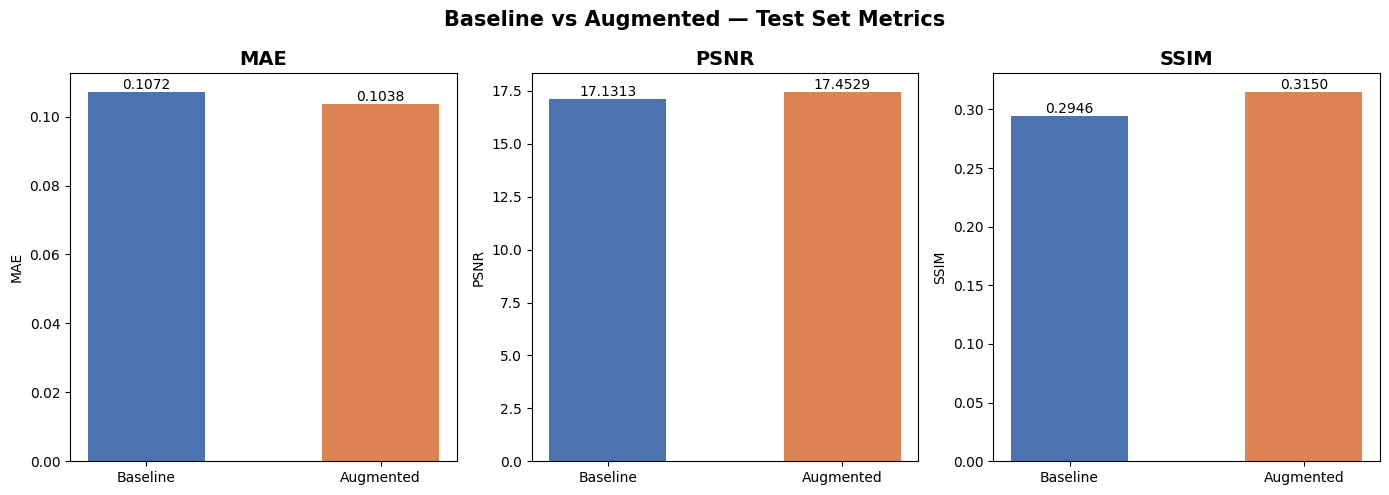

Saved to outputs/metrics_comparison.png


In [12]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

base = json.loads(Path('outputs/metrics.json').read_text())
improved = json.loads(Path('outputs_aug/metrics.json').read_text())

metrics = ['MAE', 'PSNR', 'SSIM']
base_vals = [base['mae'], base['psnr'], base['ssim']]
aug_vals = [improved['mae'], improved['psnr'], improved['ssim']]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x = np.arange(2)
labels = ['Baseline', 'Augmented']

for ax, metric, bv, av in zip(axes, metrics, base_vals, aug_vals):
    bars = ax.bar(x, [bv, av], width=0.5, color=['#4C72B0', '#DD8452'])
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, [bv, av]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Baseline vs Augmented — Test Set Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/metrics_comparison.png')

## 4) Inference Demo (Folder)

In [13]:
!python scripts/infer.py --checkpoint checkpoints/best.pt --input data/raw/maps/test --output outputs/demo_test --paired-input

Saved: outputs/demo_test/image_004.jpg
Saved: outputs/demo_test/image_013.jpg
Saved: outputs/demo_test/image_014.jpg
Saved: outputs/demo_test/image_016.jpg
Saved: outputs/demo_test/image_017.jpg
Saved: outputs/demo_test/image_023.jpg
Saved: outputs/demo_test/image_041.jpg
Saved: outputs/demo_test/image_045.jpg
Saved: outputs/demo_test/image_048.jpg
Saved: outputs/demo_test/image_050.jpg
Saved: outputs/demo_test/image_053.jpg
Saved: outputs/demo_test/image_058.jpg
Saved: outputs/demo_test/image_064.jpg
Saved: outputs/demo_test/image_072.jpg
Saved: outputs/demo_test/image_080.jpg
Saved: outputs/demo_test/image_082.jpg
Saved: outputs/demo_test/image_099.jpg
Saved: outputs/demo_test/image_102.jpg
Saved: outputs/demo_test/image_111.jpg
Saved: outputs/demo_test/image_112.jpg
Saved: outputs/demo_test/image_113.jpg
Saved: outputs/demo_test/image_115.jpg
Saved: outputs/demo_test/image_120.jpg
Saved: outputs/demo_test/image_126.jpg
Saved: outputs/demo_test/image_136.jpg
Saved: outputs/demo_test/

## Optional: Inference Demo (Single Image)

In [14]:
from pathlib import Path
import subprocess

test_dir = Path('data/raw/maps/test')
candidates = sorted([
    p for p in test_dir.glob('*')
    if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
])
if not candidates:
    raise FileNotFoundError(f'No images found in {test_dir}')

first_img = candidates[0]
print('Using:', first_img)

subprocess.run([
    'python', 'scripts/infer.py',
    '--checkpoint', 'checkpoints/best.pt',
    '--input', str(first_img),
    '--output', 'outputs/demo_single.png',
    '--paired-input',
] , check=True)

Using: data/raw/maps/test/image_004.jpg


CompletedProcess(args=['python', 'scripts/infer.py', '--checkpoint', 'checkpoints/best.pt', '--input', 'data/raw/maps/test/image_004.jpg', '--output', 'outputs/demo_single.png', '--paired-input'], returncode=0)